## Merge images

In [6]:
import datasets
import numpy as np
from PIL import Image
import random
from collections import defaultdict

In [ ]:
from pathlib import Path
from typing import Callable, Iterable
import imageio
import os

from tqdm import trange


def merge_spatial(
    images: np.ndarray,
    labels: Iterable[int],
    shape: tuple[int, int],
) -> tuple[np.ndarray, np.ndarray]:
  '''
  Given a sequence of images, merge them into a single image grid
  in np.ndarray format. 
  Merge the labels into the corresponding grid positions.

  Args:
    images: A list of PIL Image objects.
    labels: A list of corresponding labels.
    shape: A tuple (w, h) of the shape of the grid.
  '''
  w, h = shape

  # Arrange images in grid
  rows = []
  for row_idx in range(h):
    row = []
    for col_idx in range(w):
      img_idx = row_idx * w + col_idx
      row.append(images[img_idx])
    rows.append(row)

  merged_image = np.block(rows)
  labels_grid = np.array(labels).reshape(h, w)

  return merged_image, labels_grid


def merge_spatial_and_temporal(
    images: list[Image.Image],
    labels: Iterable[int],
    output_path: Path,
    shape: tuple[int, int, int],
    fps: float = 1.0,
) -> list[dict[str, str]]:
  '''
  Given a sequence of images, merge them into a png image if `shape[0] == 1`
  or a mp4 video if `shape[0] > 1` where frame in the video
  is a 2x2 grid of images. Save the merged image or video to the specified
  output path. Utilizes the `merge_spatial` and `merge_temporal` functions.
  
  Args:
    images: A list of PIL Image objects.
    labels: A numpy array of shape (n_images,) containing the labels.
    output_path: The path to save the merged image or video.
    shape: A tuple of (t, w, h) where t is the number of frames, and
    (w, h) is the shape of the grid.
    fps: Frames per second for the video.
    
  Returns:
    A list of dictionaries. If shape[0] == 1, each dictionary contains
    - 'image': the path to the saved image file
    - 'loc': (x, y) coordinates of the image in the grid
    - 'label': the label of the image corresponding to the grid position
    If shape[0] > 1, each dictionary contains
    - 'video': the path to the saved video file
    - 'loc': (t, x, y) coordinates of the video in the grid
    - 'label': the label of the image corresponding to the grid position.
  '''
  t, w, h = shape
  result = []
  labels_array = np.array(labels)
  images = [np.array(img) for img in images]

  # Create output directory if it doesn't exist
  output_path.parent.mkdir(parents=True, exist_ok=True)

  if t == 1:
    # Single frame - save as PNG

    merged_image, labels_grid = merge_spatial(images, labels, (w, h))

    # Save as PNG
    png_path = output_path.with_suffix('.png')
    Image.fromarray(merged_image).save(png_path)

    # Create result dictionaries for each position in the grid
    for y in range(h):
      for x in range(w):
        result.append({
          'image': str(png_path.name),
          'loc': (x, y),
          'label': str(labels_grid[y, x])
        })

  else:
    # Multiple frames - save as video
    frames = []
    merged_labels = []
    spatial_shape = (w, h)

    # Create frames using merge_spatial for each time step
    for frame_idx in range(t):
      start_idx = frame_idx * w * h
      end_idx = start_idx + w * h

      images_for_frame = images[start_idx:end_idx]
      labels_for_frame = labels_array[start_idx:end_idx]

      merged_frame, labels_grid = merge_spatial(images_for_frame, labels_for_frame, spatial_shape)
      frames.append(merged_frame)
      merged_labels.append(labels_grid)

    # Save as lossless MP4 video
    mp4_path = output_path.with_suffix('.mp4')

    # Use imageio with FFV1 codec for lossless compression
    with imageio.get_writer(mp4_path, fps=fps, codec='libx264', pixelformat='gray', output_params=['-crf', '0'], macro_block_size=1) as writer:
      for frame in frames:
        # Ensure frame is in the right format for video writing
        if len(frame.shape) == 2:  # Grayscale
          frame_rgb = np.repeat(frame[..., np.newaxis], 3, axis=-1)  # Convert to RGB
        else:
          frame_rgb = frame
        writer.append_data(frame_rgb)

    # Create result dictionaries for each position in the spatiotemporal grid
    for frame_idx  in range(t):
      for y in range(h):
        for x in range(w):
          result.append({
            'video': str(mp4_path.name),
            'loc': (frame_idx, x, y),
            'label': merged_labels[frame_idx][y][x]
          })

  return result


def custom_sample(
    classes: list[list[dict]],
    n_samples: int,
) -> tuple[list[Image.Image], list[int]]:
  # Sort classes by their lengths and shuffle them
  class_counts = defaultdict(list)
  for idx, class_items in enumerate(classes):
    class_counts[len(class_items)].append(idx)
  for count in class_counts:
    random.shuffle(class_counts[count])
  # Sort asending since we will pop from the back.
  class_counts = sorted(class_counts.items(), key=lambda x: x[0])
    
  # Join classes
  sample_order = [idx for sublist in class_counts for idx in sublist[1]]
  
  sample_img, sample_lbl = [], []
  for _ in range(n_samples):
    class_idx = sample_order.pop()
    item = classes[class_idx].pop()
    sample_img.append(item['image'])
    sample_lbl.append(item['label'])

  return sample_img, sample_lbl
    

def create_merged_mnist(
    dd: datasets.DatasetDict,
    data_dir: Path,
    shape: tuple[int, int, int],
    fps: float = 1.0,
) -> datasets.DatasetDict:
  '''
  Create a merged MNIST dataset from the original dataset, utilizing the
  `merge_spatial_and_temporal` function.
  
  Args:
    dd: The original DatasetDict. Each split contains two features: image and label
    data_dir: The directory to save the video files. The directory should be
    structured as follows: <data_dir>/<split_name>/<merged_item_id_left_padded_w_default>
    shape: A tuple of (t, w, h) where t is the number of frames, and
    (w, h) is the shape of the grid.
    fps: Frames per second for the video.
    
  Returns:
    A new DatasetDict with the same splits as the original dataset, but the items
    should be the same format as the return value of `merge_spatial_and_temporal`.
  '''
  new_splits = {}
  images_per_frame = np.prod(shape[1:])
  
  for split_name, split_data in dd.items():
    n_merged_items = len(split_data) // images_per_frame // shape[0]
    split_data = split_data.shuffle(seed=42)
    
    # Group by classes
    classes = [[] for _ in range(10)]
    for item in split_data:
      classes[item['label']].append(item)
      
    # Used for sampling
    class_counts = {len(classes[0]): [i for i in range(len(classes))]}

    all_results = []

    # Process each merged item
    for merged_idx in trange(n_merged_items):
      padded_id = split_name + "_" + str(merged_idx).zfill(5)
      output_path = data_dir / padded_id
      sample_images, sample_labels = [], []
      for _ in range(shape[0]):
        samples = custom_sample(classes, images_per_frame)
        assert len(samples[1]) == len(set(samples[1])), "Labels should be unique per sample frame"
        sample_images.extend(samples[0])
        sample_labels.extend(samples[1])
      
      # Use merge_spatial_and_temporal to create and save the merged data
      merged_results = merge_spatial_and_temporal(
        sample_images,
        sample_labels,
        output_path,
        shape,
        fps
      )

      # Add merged item ID to each result
      for result in merged_results:
        result['id'] = merged_idx
        all_results.append(result)

    # Create new dataset from results
    new_splits[split_name] = datasets.Dataset.from_list(all_results)

  return datasets.DatasetDict(new_splits)


In [10]:
import datasets

for mode, shape in zip(['spatial', 'temporal', 'final'], [(1, 2, 2), (10, 1, 1), (10, 2, 2)]):

  dd = datasets.load_dataset("zalando-datasets/fashion_mnist")
  dsname = f'fashion_{mode}'
  dd = dd.cast_column("image", datasets.Image(decode=True))
  data_dir = Path(f"/scratch/xiaowenz/datasets/{dsname}/data/images")
  merged_ds = create_merged_mnist(dd, data_dir, shape, fps=1.0)
  merged_ds = merged_ds.cast_column('label', datasets.ClassLabel(num_classes=10, names=['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']))
  merged_ds.push_to_hub(f"withcomment/{dsname}")

100%|██████████| 2500/2500 [00:07<00:00, 322.25it/s]


Casting the dataset:   0%|          | 0/60000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/60 [00:00<?, ?ba/s]

...

Casting the dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/60 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

## Experiments

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path
os.chdir('/home/xiaowenz/finetune')
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

In [9]:
import transformers
import torch
from copy import deepcopy
model_base = transformers.Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "/model-weights/Qwen2.5-VL-3B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="cuda:0",
    attn_implementation="eager",
)
model_default = transformers.Qwen2_5_VLForConditionalGeneration.from_pretrained(
  "/scratch/xiaowenz/checkpoints/Qwen2_5_3_fashion_final#1000_default/last",
  torch_dtype=torch.bfloat16,
  device_map="cuda:1",
  attn_implementation="eager",
)

model_video = transformers.Qwen2_5_VLForConditionalGeneration.from_pretrained(
  "/scratch/xiaowenz/checkpoints/Qwen2_5_3_fashion_final#1000_video/last",
  torch_dtype=torch.bfloat16,
  device_map="cuda:2",
  attn_implementation="eager",
)

gen_config = deepcopy(model_base.generation_config)

gen_config.max_new_tokens = 8
gen_config.do_sample = False

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np

from qwenvl.data.input_processor import VISION_END, VISION_START
from qwenvl.module import create_module, create_strategies
from qwenvl.argument import DataArguments, ProcessingArguments
from qwenvl.train import set_processor
from qwenvl.data.prompts import *

data_args = DataArguments(
    dataset_use='fashion_final',
    split='test',
    packing=False,
    model_max_length=3072,)

proc_args_default = ProcessingArguments(
    use_chat_template=True,
    sys_prompt="default",
    usr_prompt='',
    add_generation_prompt=True,
    use_bf16=True,
    image_min_pixels=224 * 224,
    video_min_pixels=224 * 224,
    base_interval=0.5
)

proc_args_video = deepcopy(proc_args_default)
proc_args_video.sys_prompt = "default,video"

processor_default = transformers.AutoProcessor.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct", use_fast=True)
processor_video = transformers.AutoProcessor.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct", use_fast=True)

processor_default = set_processor(processor_default, proc_args_default, data_args)
strategies, cp_default, ip_default = create_strategies(processor_default, data_args, proc_args_default, rank=0, additional_kwargs={'shuffle': 2})
ds, collate_default = create_module(data_args, strategies, cp_default, ip_default)

processor_video = set_processor(processor_video, proc_args_video, data_args)
strategies, cp_video, ip_video = create_strategies(
    processor_video, data_args, proc_args_video, rank=0, additional_kwargs={'shuffle': 2})

_, collate_video = create_module(data_args, strategies, cp_video, ip_video)
stats = {}

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


2025-08-10 15:27:23,937 - qwenvl.module - WARNING - CFT prompt  not found, not using it.
2025-08-10 15:27:23,939 - qwenvl.module - WARNING - User prompt  not found, not using it.
2025-08-10 15:27:23,940 - qwenvl.module - INFO - Using system prompt default
2025-08-10 15:27:24,319 - qwenvl.module - INFO - Creating module for dataset fashion_final with split test
2025-08-10 15:27:25,442 - qwenvl.module - INFO - Applying strategy AddIdStrategy
2025-08-10 15:27:25,443 - qwenvl.data.preprocess - INFO - id column already exists in the dataset.
2025-08-10 15:27:25,445 - qwenvl.data.preprocess - INFO - id column already exists in the dataset.
2025-08-10 15:27:25,445 - qwenvl.module - INFO - Applying strategy SaveStrategy
2025-08-10 15:27:25,446 - qwenvl.data.preprocess - INFO - Saving dataset to /scratch/xiaowenz/datasets/fashion_final/data/dataset.


Saving the dataset (0/1 shards):   0%|          | 0/60000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

2025-08-10 15:27:25,535 - qwenvl.data.preprocess - INFO - Temporary dataset saved to /tmp/tmp4rw9rnsz/dataset_tmp.
2025-08-10 15:27:25,553 - qwenvl.data.preprocess - INFO - Removed existing dataset at /scratch/xiaowenz/datasets/fashion_final/data/dataset.
2025-08-10 15:27:25,585 - qwenvl.data.preprocess - INFO - Dataset saved to /scratch/xiaowenz/datasets/fashion_final/data/dataset.
2025-08-10 15:27:25,666 - qwenvl.module - INFO - Example from dataset: [[{'video': 'test_00000.mp4', 'loc': [0, 0, 0], 'label': 8, 'id': 0}]]
2025-08-10 15:27:25,667 - qwenvl.module - INFO - Example after conversation processing: [[{'role': 'system', 'content': 'You are a helpful assistant.'}, {'role': 'user', 'content': [{'video': '/scratch/xiaowenz/datasets/fashion_final/data/videos/test_00000.mp4'}, {'text': 'What type of clothing is in the top-left corner during the 1st second of this video? Choose exactly one from the following options: T-shirt/top, Shirt, Bag, Dress, Coat, Sneaker, Trouser, Sandal, Pu

Saving the dataset (0/1 shards):   0%|          | 0/60000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

2025-08-10 15:27:26,585 - qwenvl.data.preprocess - INFO - Temporary dataset saved to /tmp/tmpa1abmetj/dataset_tmp.
2025-08-10 15:27:26,599 - qwenvl.data.preprocess - INFO - Removed existing dataset at /scratch/xiaowenz/datasets/fashion_final/data/dataset.
2025-08-10 15:27:26,629 - qwenvl.data.preprocess - INFO - Dataset saved to /scratch/xiaowenz/datasets/fashion_final/data/dataset.
2025-08-10 15:27:26,700 - qwenvl.module - INFO - Example from dataset: [[{'video': 'test_00000.mp4', 'loc': [0, 0, 0], 'label': 8, 'id': 0}]]
2025-08-10 15:27:26,701 - qwenvl.module - INFO - Example after conversation processing: [[{'role': 'system', 'content': 'You are a helpful assistant.'}, {'role': 'system', 'content': "Focus attention on the primary subject's main action. Prioritize the temporal sequence from the action's start to its conclusion, emphasizing the peak. Within this sequence, isolate the key visual details of the subject and its direct interactions."}, {'role': 'user', 'content': [{'video

In [ ]:
import random

transformers.logging.set_verbosity_error()

VS_ID = processor_default.tokenizer.convert_tokens_to_ids(VISION_START)
VE_ID = processor_default.tokenizer.convert_tokens_to_ids(VISION_END)

custom_sample = random.sample(range(len(ds) // 40), 30)
# Cannot include the 10th frame due to difference in token length
sample = [i + idx * 40 for idx in custom_sample for i in range(4 * 9)]
group_shape = (10, 8, 8)


def group_vision_attns(flat_attn, group_shape, take_mean):
  '''Reshape the last dimension into quadrants.'''
  t, h, w = group_shape
  attn = flat_attn.reshape(
    *flat_attn.shape[:-1], t, h, -1)
  if h > 1 and w > 1:
    grouped_attn = torch.zeros(
      *flat_attn.shape[:-1], t, 4, h // 2, w // 2)
    grouped_attn[..., 0, :, :] = attn[..., :h // 2, :w // 2] # top-left
    grouped_attn[..., 1, :, :] = attn[..., :h // 2, w // 2:] # top-right
    grouped_attn[..., 2, :, :] = attn[..., h // 2:, :w // 2] # bottom-left
    grouped_attn[..., 3, :, :] = attn[..., h // 2:, w // 2:] # bottom-right
  else:
    grouped_attn = attn
    
  if take_mean:
    grouped_attn = grouped_attn.mean(dim=(-1, -2))
  if h > 1 and w > 1:
    return grouped_attn.reshape(*flat_attn.shape[:-1], 4 * t)
  
  return grouped_attn.reshape(*flat_attn.shape[:-1], t)


def generate_and_extract_attentions(model, ip, collate_fn, group_shape, sample):
  attns = []
  samples = []

  with torch.no_grad():
    for idx in tqdm(sample):
      item = ds[idx]
      inputs = collate_fn(item)

      vs_idx = inputs.input_ids[0].tolist().index(VS_ID) + 1
      ve_idx = inputs.input_ids[0].tolist().index(VE_ID)
      n_vision_tokens = ve_idx - vs_idx
      
      
      output = model.generate(**inputs.to(model.device), return_dict_in_generate=True,
                          output_attentions=True, generation_config=gen_config)
      
      # attn grouped by layers
      attn = torch.stack(output.attentions[0], dim=0).detach().cpu()
      vis_attn = attn[..., -1, vs_idx:ve_idx]
      vis_attn = group_vision_attns(vis_attn, group_shape=group_shape, take_mean=True)
      attn = torch.cat([attn[..., -1, :vs_idx], vis_attn, attn[..., -1, ve_idx:]], dim=-1)
      ve_idx = vs_idx + vis_attn.shape[-1]
      attns.append(attn)
      
      generated_ids = output.sequences[0][len(inputs.input_ids[0]):]
      
      item = deepcopy(item[0])
      item['model_answer'] = ip.tokenizer.decode(generated_ids, skip_special_tokens=True)
      item['combined_ids'] = output.sequences[0]
      samples.append(item)
  print(vis_attn.shape, attn.shape, vs_idx, ve_idx, n_vision_tokens)
  # attns.shape = (n_sample, layers, batch_size, heads, k_len)
  attns = torch.stack(attns, dim=0)
  return attns, samples, vs_idx, ve_idx


def get_is_correct(samples):
  return torch.tensor([ds.ds.features['label'].int2str(sample['label']).startswith(sample['model_answer']) for sample in samples], dtype=torch.float32)

all_vars = globals()
for model in ['base', 'default', 'video']:
  for prompt in ['default', 'video']:
    attns, samples, vs_id, ve_id = generate_and_extract_attentions(
      all_vars[f'model_{model}'], all_vars[f'ip_{prompt}'], all_vars[f'collate_{prompt}'], group_shape, sample
    )
    stats[f'{model}_{prompt}'] = {
      'attns': attns,
      'samples': samples,
      'vs_id': vs_id,
      've_id': ve_id,
      'is_correct': get_is_correct(samples)
    }
    print(f"{model}_{prompt}", stats[f'{model}_{prompt}']['is_correct'].mean())


100%|██████████| 1080/1080 [17:26<00:00,  1.03it/s]


torch.Size([36, 1, 16, 40]) torch.Size([36, 1, 16, 117]) 15 55 640
base_default tensor(0.1065)


100%|██████████| 1080/1080 [18:28<00:00,  1.03s/it]


torch.Size([36, 1, 16, 40]) torch.Size([36, 1, 16, 167]) 65 105 640
base_video tensor(0.0870)


100%|██████████| 1080/1080 [17:23<00:00,  1.04it/s]


...

100%|██████████| 1080/1080 [18:19<00:00,  1.02s/it]


torch.Size([36, 1, 16, 40]) torch.Size([36, 1, 16, 167]) 65 105 640
default_video tensor(0.1009)


100%|██████████| 1080/1080 [17:20<00:00,  1.04it/s]


torch.Size([36, 1, 16, 40]) torch.Size([36, 1, 16, 117]) 15 55 640
video_default tensor(0.0972)


100%|██████████| 1080/1080 [18:16<00:00,  1.02s/it]


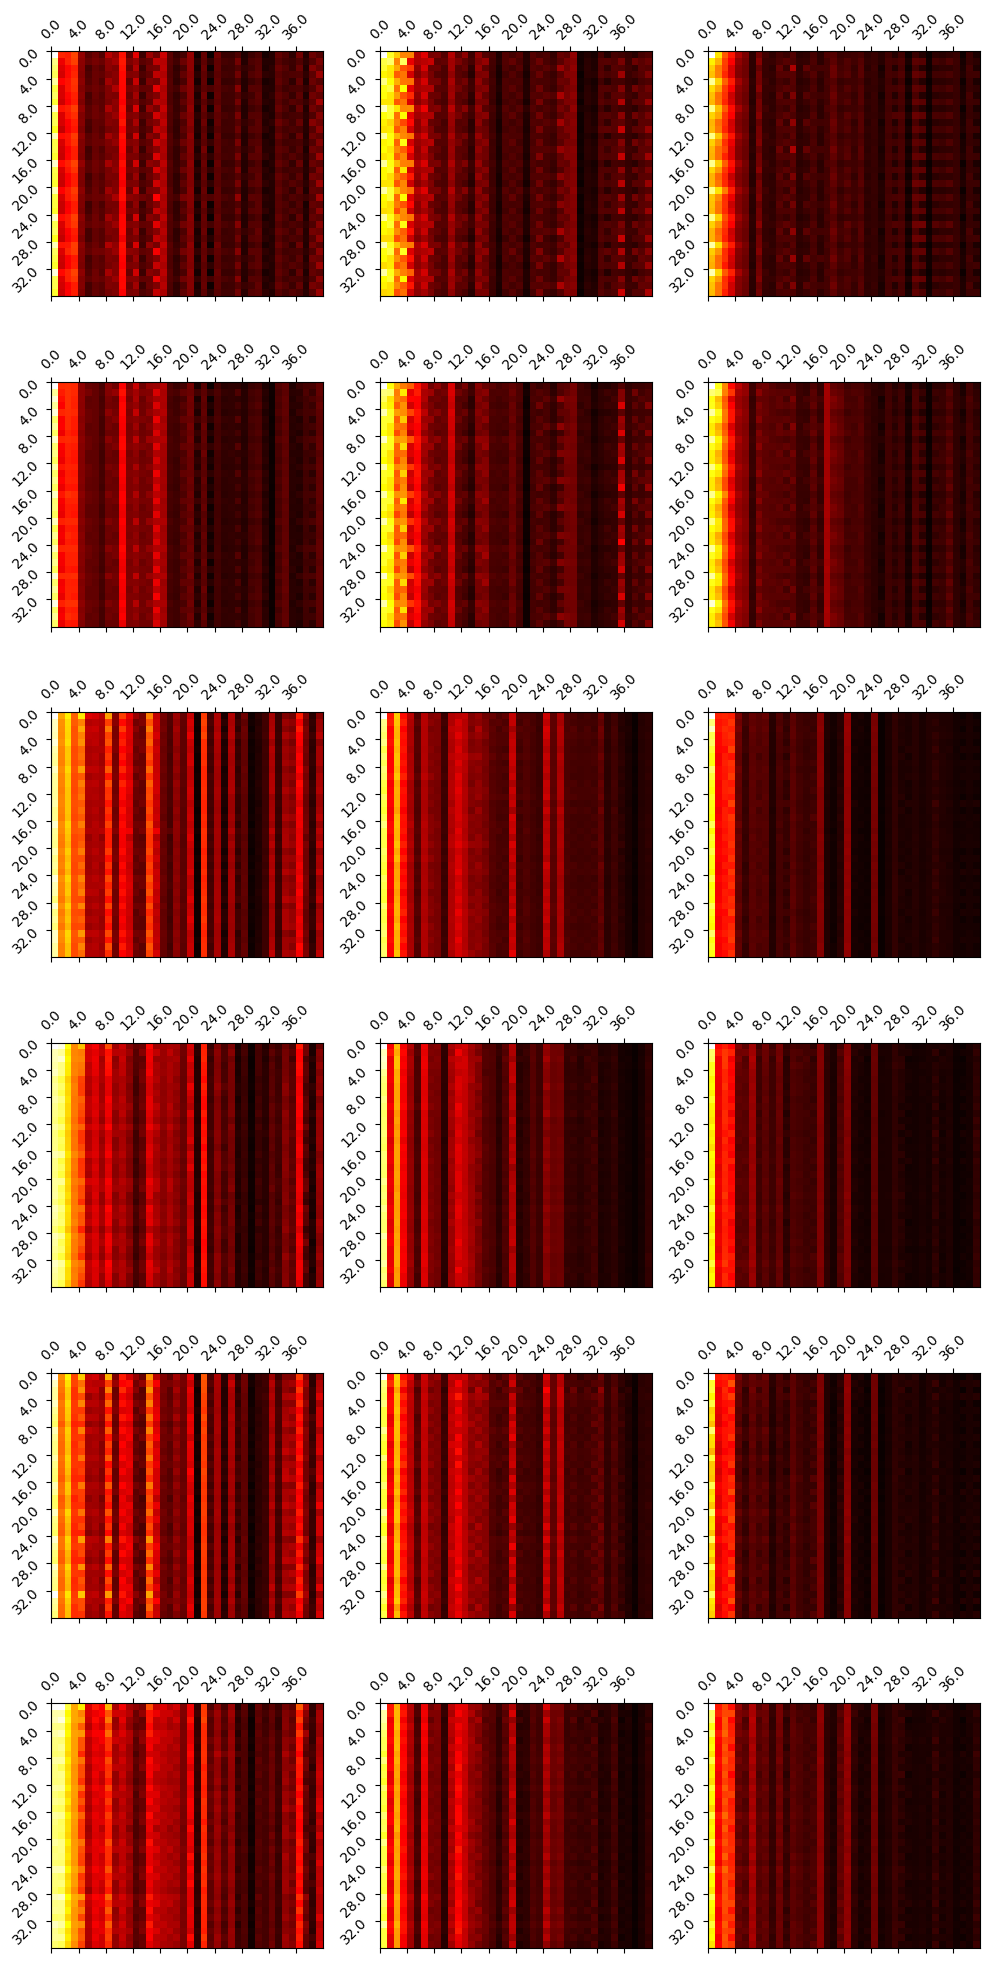

In [ ]:
for k, v in stats.items():
  stats[k]['avg_attns'] = v['attns'].reshape(30, 36, *v['attns'].shape[1:]).mean(dim=0)
def plot_attn(ax, attns, vs_id, ve_id):
  avg_attns = attns[..., vs_id:ve_id].to(torch.float32).mean(dim=(1, 2, 3))
  ax.matshow(avg_attns.numpy(), cmap='hot', aspect='1')
  y_tick_pos = np.arange(0, len(avg_attns), 4) - 0.5
  ax.set_yticks(y_tick_pos, labels=y_tick_pos + 0.5, rotation=45)
  x_tick_pos = np.arange(0, 40, 4) - 0.5
  ax.set_xticks(x_tick_pos, labels=x_tick_pos + 0.5, rotation=45)
  return avg_attns

fig, axes = plt.subplots(6, 1, figsize=(10, 20))

for row, (config, stat) in zip(axes, stats.items()):
  for i, ax in enumerate(row):
    plot_attn(ax, stat['attns'][i * 36:(i + 1) * 36], stat['vs_id'], stat['ve_id']);
fig.tight_layout()
fig.show()

In [ ]:
from matplotlib import colormaps as cm

def layer_head_correlation(attns: torch.Tensor, is_correct, corr_fn, ax):

  if corr_fn == spearmanr:
    corr, pvals = [], []
    for layer_idx in range(attns.shape[0]):
      for head_idx in range(attns.shape[1]):
        result = spearmanr(is_correct, attns[layer_idx, head_idx])
        corr.append(result.statistic)
        pvals.append(result.pvalue)
    corr = np.array(corr).reshape(attns.shape[0], attns.shape[1])
    pvals = np.array(pvals).reshape(attns.shape[0], attns.shape[1])
  else:
    result = pearsonr(is_correct, attns, axis=-1)
    corr = result.statistic
    pvals = result.pvalue
    
  corr[pvals > 0.05] = np.nan  # Mask out non-significant correlations

  coolwarm = cm['coolwarm'].copy()
  coolwarm.set_bad('lightgray')
  cb = ax.matshow(corr, cmap=coolwarm, vmin=-1, vmax=1)
  ax.set_title('Layer-Head Correlation with Correctness')
  ax.set_xlabel('Head Index')
  ax.set_ylabel('Layer Index')
  return cb
  
def layer_head_correlation_by_qtype(attns, vs_id, ve_id, is_correct, corr_fn):
  attns = attns.reshape(-1, 4, *attns.shape[1:]).transpose(0, 1)
  avg_attn = attns[..., -1, vs_id + 1:ve_id].to(torch.float32).mean(dim=-1)
  avg_attn = avg_attn.transpose(1, -1)
  is_correct = is_correct.reshape(-1, 4).T
  fig, axes = plt.subplots(2, 2, figsize=(16, 10))
  for (idx, (qtype, ax)) in enumerate(zip(['top-left', 'top-right', 'bottom-left', 'bottom-right'], axes.flat)):
    ax.set_title(f'Attention for {qtype} question')
    cb = layer_head_correlation(avg_attn[idx], is_correct[idx], corr_fn, ax)
    fig.colorbar(cb, ax=ax)
  
  fig.tight_layout()
  fig.show()
  

layer_head_correlation_by_qtype(attns_0, vs_id, ve_id, is_correct_0, pearsonr)
# layer_head_correlation_by_qtype(attns_1, is_correct_1, pearsonr)
# layer_head_correlation_by_qtype(attns_2, is_correct_2, pearsonr)

In [ ]:
def key_token_correlation(attns, is_correct, corr_fn, ax=None, index=0, label=None):
  if ax is None:
    ax = plt

  attns = attns.mean(dim=(1, 2))
  is_correct = is_correct.view(-1, 1)
  
  result = corr_fn(is_correct, attns, axis=0)
  
  insig_idx = result.pvalue >= 0.05
  
  # Get color from matplotlib default cycle
  prop_cycle = plt.rcParams['axes.prop_cycle']
  colors = prop_cycle.by_key()['color']
  base_color = colors[index % len(colors)]
  
  x_offset = index * 1.2 + np.arange(4) * 0.2
  ax.bar(x_offset, result.statistic, color=base_color, width=0.2)
  gray_tinted = (0.4, 0.4, 0.4, 0.7)
  ax.bar(x_offset[insig_idx], result.statistic[insig_idx], color=gray_tinted, width=0.2)
  group_centers = np.arange(4) * 1.2 + 0.3
  ax.set_xticks(group_centers)
  ax.set_xticklabels(['T-L', 'T-R', 'B-L', 'B-R'])
  ax.set_xlabel('Question type')
  ax.set_ylabel('Correlation with Correctness')
  ax.grid(True, alpha=0.3)

def plot_token_acc_correlation(attns, vs_id, ve_id, is_correct):
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))

  attns = attns.reshape(-1, 4, *attns_0.shape[1:]).transpose(1, 0)
  attns = group_vision_attns(attns[..., -1, vs_id + 1:ve_id], quadrant_width_n_tokens=4).to(torch.float32).mean(dim=(-1, -2))
  norm_attns = attns / attns.sum(dim=-1, keepdim=True)
  is_correct = is_correct.reshape(-1, 4).transpose(1, 0)
  
  coord_labels = ['T-L Question', 'T-R Question', 'B-L Question', 'B-R Question']

  for i in range(4):
    key_token_correlation(attns[i], is_correct[i], corr_fn=pearsonr, ax=axes[0], index=i)
    key_token_correlation(norm_attns[i], is_correct[i], corr_fn=pearsonr, ax=axes[1], index=i)


  fig.tight_layout()
  fig.show()

plot_token_acc_correlation(attns_0, vs_id_0, ve_id_0, is_correct_0)
# plot_token_acc_correlation(attns_1, is_correct_1)
# plot_token_acc_correlation(attns_2, is_correct_2)

In [ ]:

def key_token_correlation(attns, is_correct, corr_fn, ax=None, label=None):
  avg_attn = attns[..., -1, :].mean(dim=(1, 2))
  grouped_attn = group_vision_attns(attns[..., -1, 15:79], quadrant_width_n_tokens=4).reshape(*attns.shape[:-2], -1)
  avg_attn[..., 15:79] = grouped_attn.mean((1, 2))
  avg_attn = avg_attn.to(torch.float32)
  is_correct = is_correct.view(-1, 1)
  result = corr_fn(is_correct, avg_attn, axis=0)
  insig_idx = result.pvalue >= 0.1
  x_offset = np.arange(avg_attn.shape[-1])
  
  is_img_token = np.zeros_like(x_offset, dtype=bool)
  is_img_token[15:79] = True
  is_img_token[-7] = True
  is_img_token[-8] = True
  
  if ax is None:
    ax = plt
    
  ax.bar(x_offset[~is_img_token], result.statistic[~is_img_token], width=0.5, label=label if label else None)
  ax.bar(x_offset[is_img_token], result.statistic[is_img_token], color='red', width=0.5, label=label if label else None)
  gray_tinted = (0.4, 0.4, 0.4, 0.7)
  ax.bar(x_offset[insig_idx], result.statistic[insig_idx], 
          color=gray_tinted, width=0.5)
  ax.set_xticks(np.arange(15, 80, 16))

def plot_token_acc_correlation(attns, is_correct):
  fig, axes = plt.subplots(4, 1, figsize=(12, 16))

  attns = attns.reshape(-1, 4, *attns_0.shape[1:]).transpose(1, 0)
  is_correct = is_correct.reshape(-1, 4).transpose(1, 0)


  for i in range(4):
    key_token_correlation(attns[i], is_correct[i], corr_fn=pearsonr, ax=axes[i])

  fig.tight_layout()
  fig.show()

plot_token_acc_correlation(attns_0, is_correct_0)
plot_token_acc_correlation(attns_1, is_correct_1)
plot_token_acc_correlation(attns_2, is_correct_2)